<a href="https://colab.research.google.com/github/Haricharan-Venkatesh/exploratory-data-analysis-lab-exercises/blob/main/Exp7_25.08.2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import parallel_coordinates, andrews_curves
from sklearn.datasets import load_iris

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12


In [15]:
if not os.path.exists('iris.csv'):
    raw_iris = load_iris()
    df_temp = pd.DataFrame(raw_iris.data, columns=['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'])
    df_temp['Species'] = [raw_iris.target_names[i] for i in raw_iris.target]
    df_temp['Species'] = 'Iris-' + df_temp['Species']
    df_temp.insert(0, 'Id', range(1, len(df_temp) + 1))
    df_temp.to_csv('iris.csv', index=False)

df = pd.read_csv('iris.csv')
features_df = df.drop(columns=['Id'])
numeric_cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
print(df.head())


   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


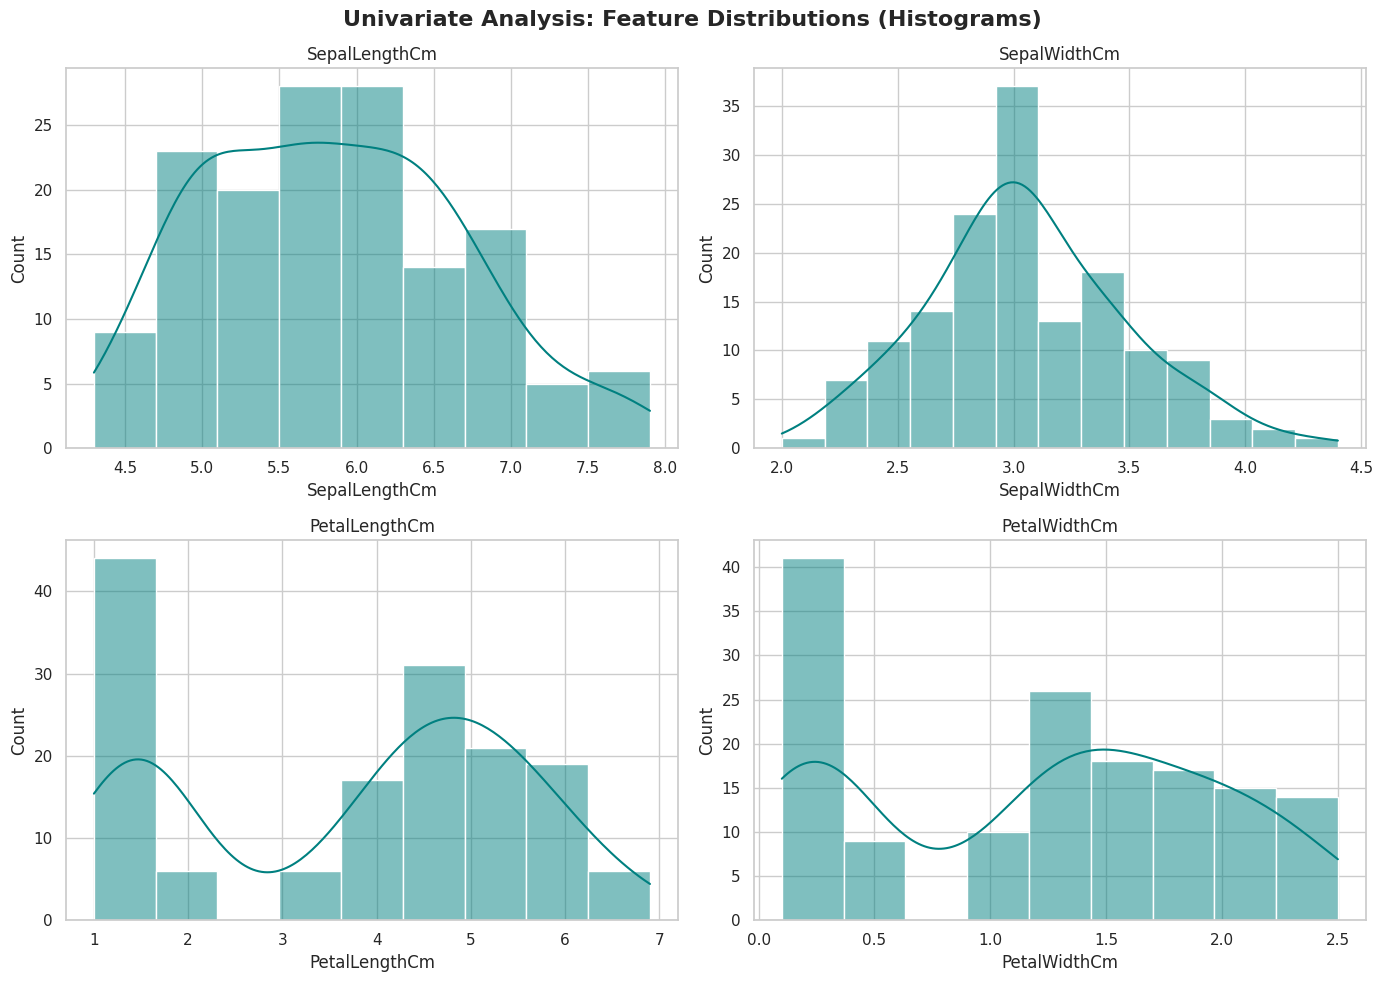

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Univariate Analysis: Feature Distributions (Histograms)', fontsize=16, fontweight='bold')
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(data=df, x=col, kde=True, ax=ax, color='teal')
    ax.set_title(col)
plt.tight_layout()
plt.show()


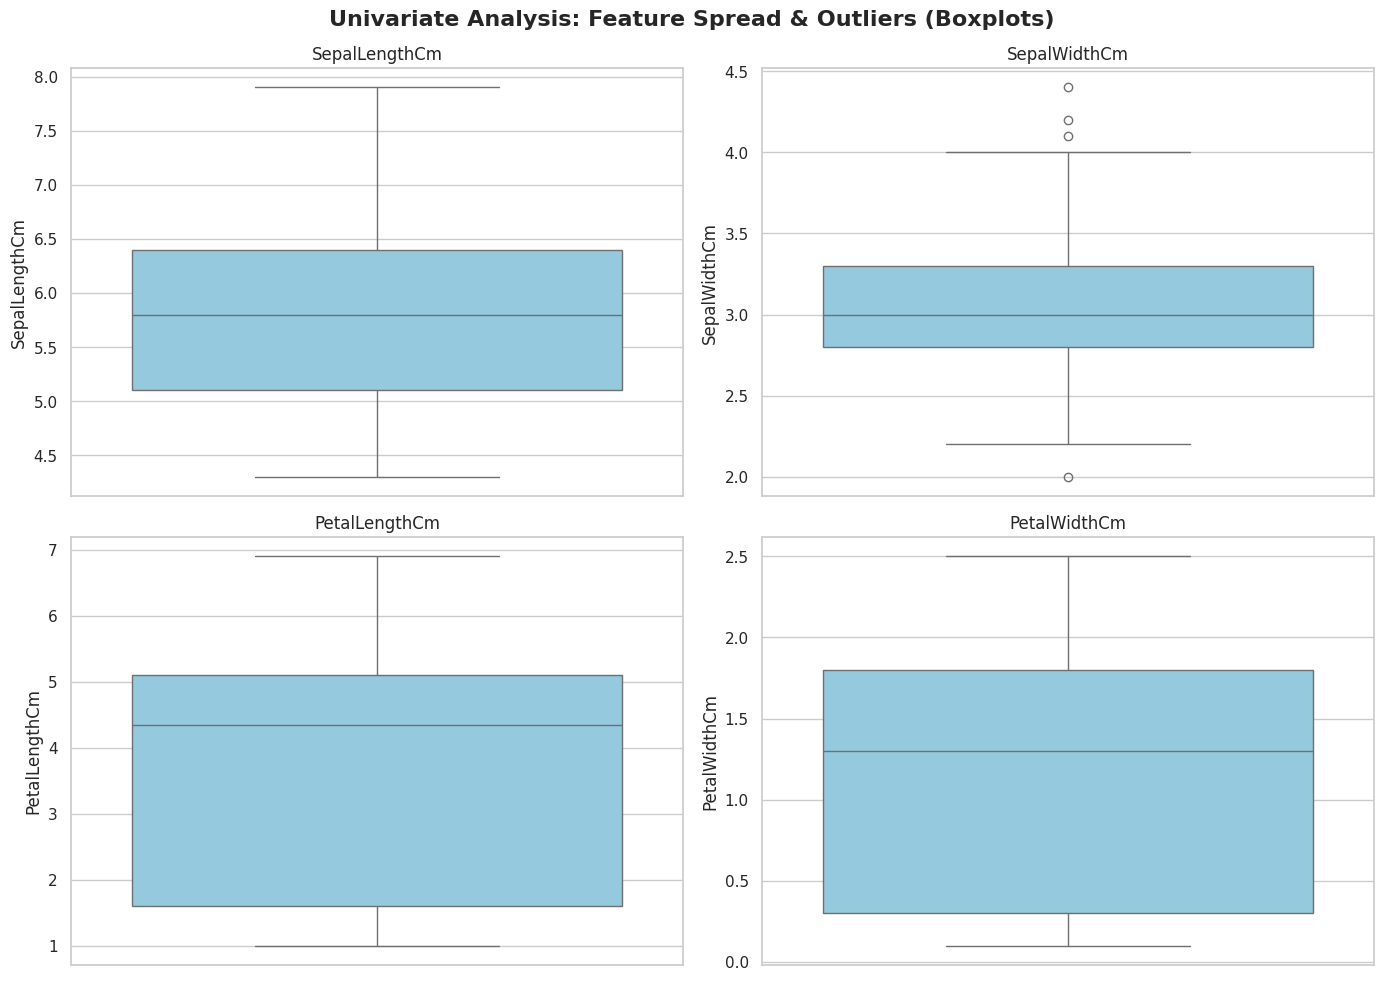

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Univariate Analysis: Feature Spread & Outliers (Boxplots)', fontsize=16, fontweight='bold')
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(data=df, y=col, ax=ax, color='skyblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()


/tmp/ipykernel_517/2257485200.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Species', palette='Set2')


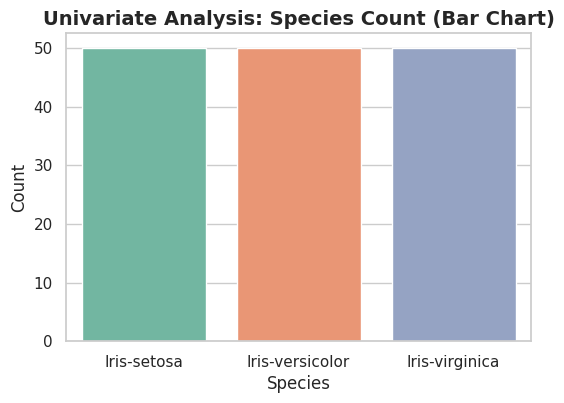

In [18]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Species', palette='Set2')
plt.title('Univariate Analysis: Species Count (Bar Chart)', fontsize=14, fontweight='bold')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()


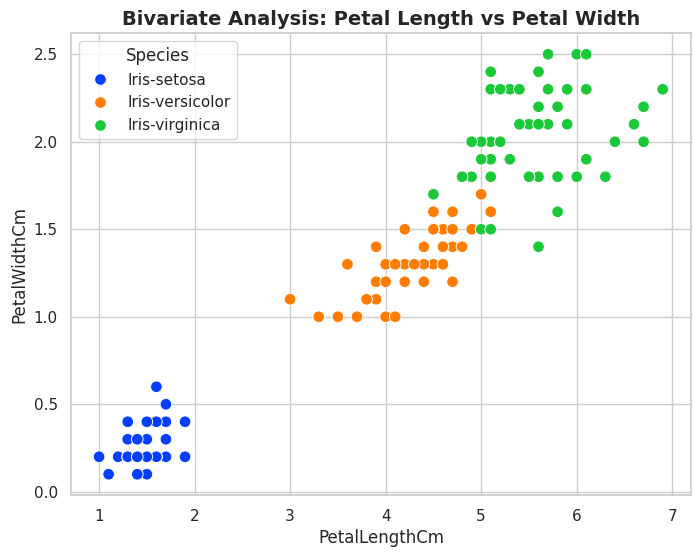

In [19]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PetalLengthCm', y='PetalWidthCm', hue='Species', palette='bright', s=70)
plt.title('Bivariate Analysis: Petal Length vs Petal Width', fontsize=14, fontweight='bold')
plt.show()


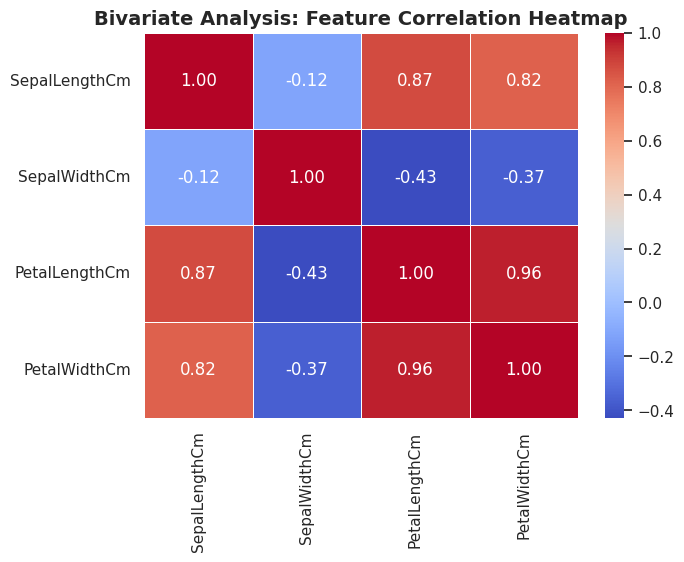

In [20]:
plt.figure(figsize=(7, 5))
correlation_matrix = features_df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Bivariate Analysis: Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.show()


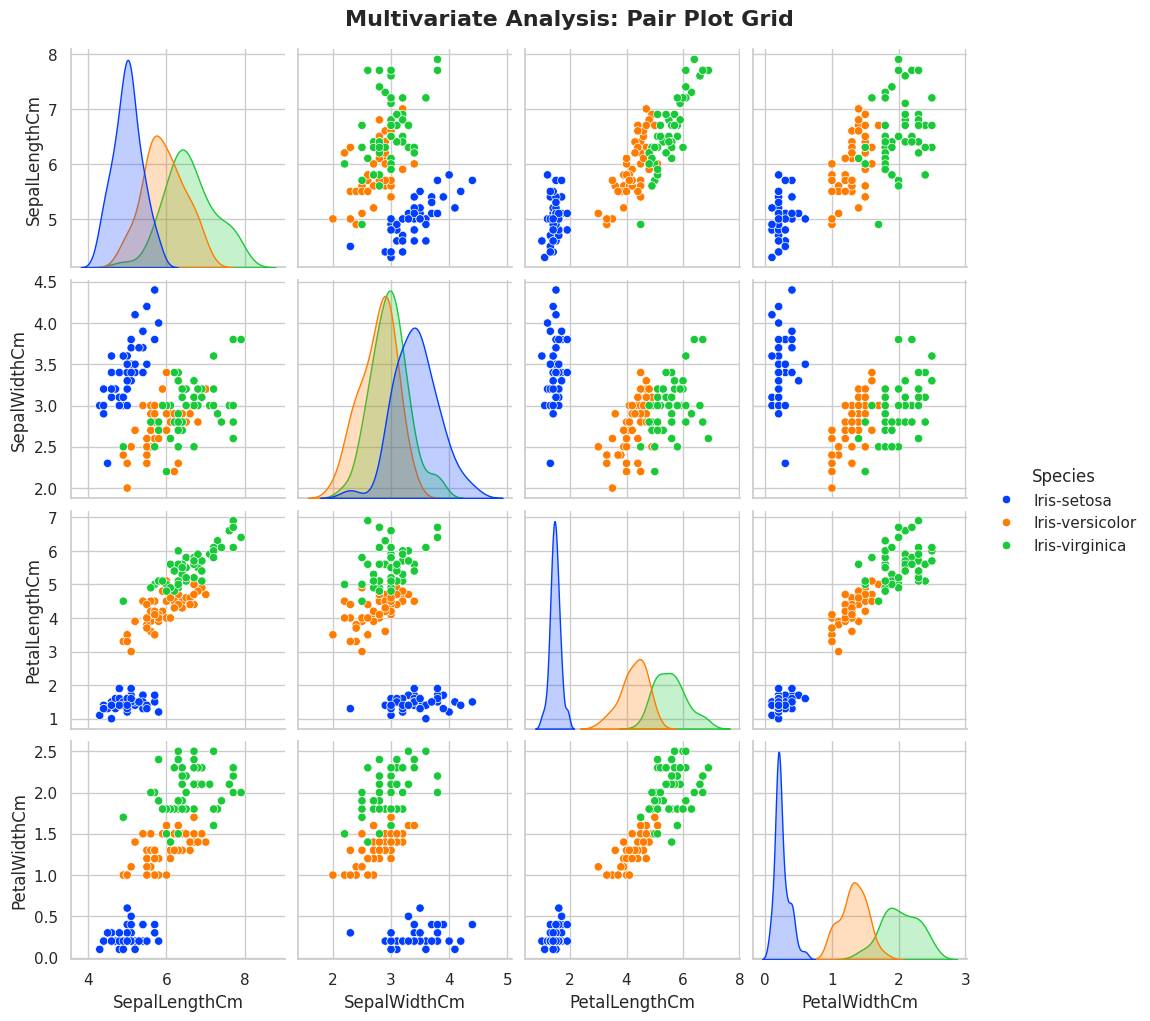

In [21]:
pair_plot = sns.pairplot(features_df, hue='Species', palette='bright', diag_kind='kde')
pair_plot.fig.suptitle('Multivariate Analysis: Pair Plot Grid', y=1.02, fontsize=16, fontweight='bold')
plt.show()


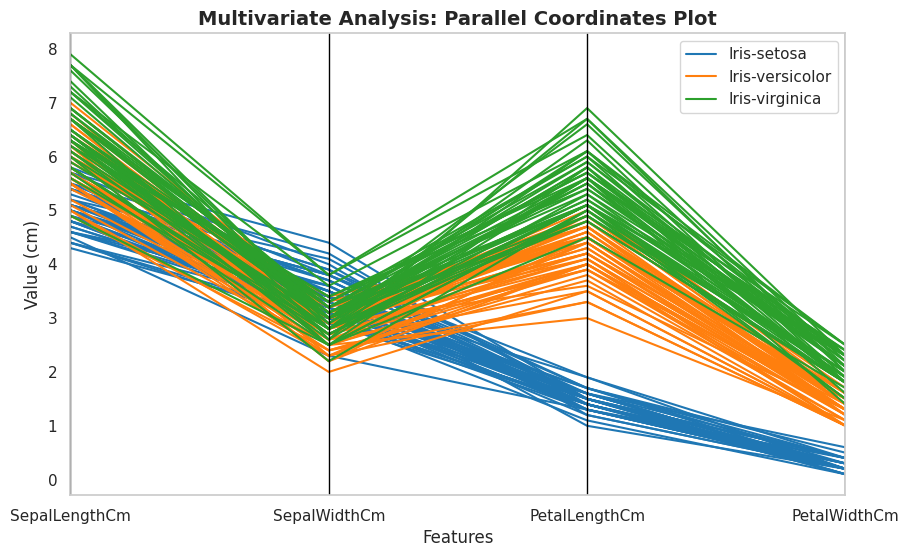

In [22]:
plt.figure(figsize=(10, 6))
parallel_coordinates(features_df, 'Species', color=('#1f77b4', '#ff7f0e', '#2ca02c'))
plt.title('Multivariate Analysis: Parallel Coordinates Plot', fontsize=14, fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Value (cm)')
plt.show()


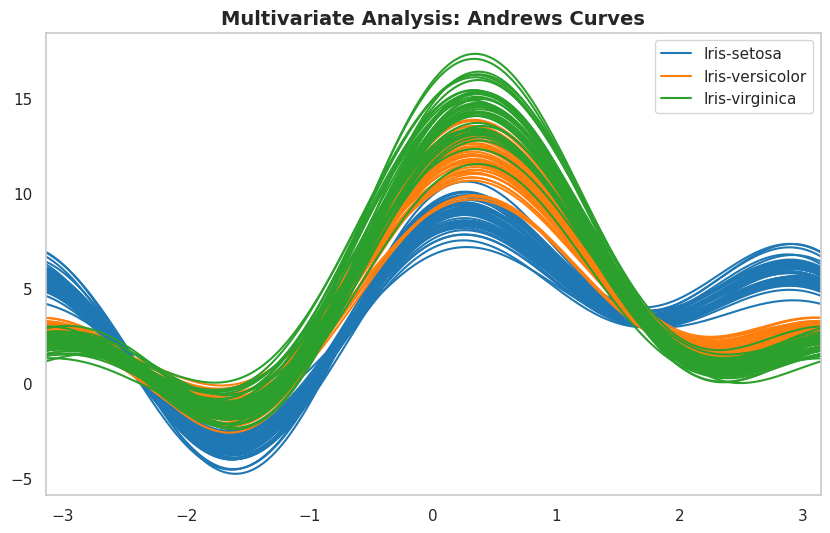

In [23]:
plt.figure(figsize=(10, 6))
andrews_curves(features_df, 'Species', color=('#1f77b4', '#ff7f0e', '#2ca02c'))
plt.title('Multivariate Analysis: Andrews Curves', fontsize=14, fontweight='bold')
plt.show()


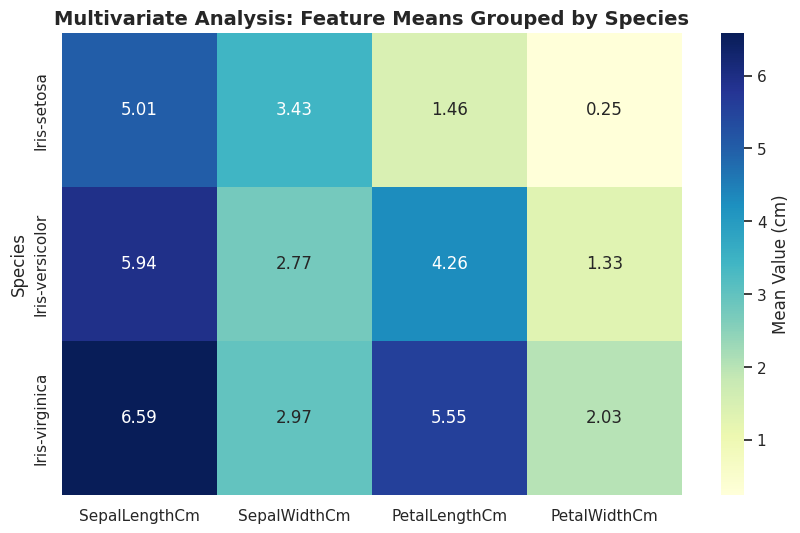

In [24]:
plt.figure(figsize=(10, 6))
grouped_means = features_df.groupby('Species').mean()
sns.heatmap(grouped_means, annot=True, cmap='YlGnBu', fmt=".2f", cbar_kws={'label': 'Mean Value (cm)'})
plt.title('Multivariate Analysis: Feature Means Grouped by Species', fontsize=14, fontweight='bold')
plt.show()
